# Solving the default layout instance with `pyomo-cp`

This example comes from a deployed Streamlit facility-layout application (part of [griffith-pse.com](https://griffith-pse.com)). The app builds a **`pyomo.gdp`** model (a 4-way non-overlap
disjunction per pair of blocks) and normally solves it by reformulating the
disjunctions to a MILP (big-M) and calling **Gurobi**.

This notebook takes the *identical* `pyomo.gdp` model and solves it with
**CP-SAT** (Google OR-Tools) instead, through the
[`pyomo-cp`](https://github.com/devin-griff/pyomo-cp) package. The disjunctions
map to native reified CP constraints rather than being reformulated, and the
continuous coordinates are placed on the integer grid the instance already
lives on. The result is the same optimum the app's MILP path finds: **98**.

> Install once: `pip install "pyomo-cp[cpsat]"` (pulls in Pyomo and OR-Tools).

In [1]:
# !pip install "pyomo-cp[cpsat]"
import random
import time

import pyomo.environ as pyo
from pyomo.gdp import Disjunction

import pyomo_cp  # registers the 'cp.discretize' transform and the 'cpsat' solver

## 1. The default instance

The app's default instance is `seed = 1` with 15 objects: a fixed 9x1 pipe
**rack** (object 1) plus 14 small units, each with a length, width, unit pipe
cost, and a north/south rack end it ties into. Two zero-length **tie-in
headers** are appended (indices 16 and 17) as virtual pipe targets pinned to
the rack's ends. This is exactly the `_gen_objects` / `_objs_to_inputs` logic
from `app.py`.

In [2]:
RACK_LEN, RACK_WID = 9, 1
DEFAULT_SEED, DEFAULT_N = 1, 15


def gen_objects(seed, objs):
    """Roll dims/costs/side for non-rack objects; rack stays fixed. Same RNG
    sequence as the app."""
    rng = random.Random(seed)
    objs = list(objs)
    rack = objs[0]
    length, width, cost = {rack: RACK_LEN}, {rack: RACK_WID}, {rack: 0}
    for oid in objs[1:]:
        length[oid] = rng.randint(1, 3)
        width[oid] = rng.randint(1, 3)
        cost[oid] = rng.randint(1, 3)
    side = {oid: rng.choice(["N", "S"]) for oid in objs[1:]}
    return objs, length, width, cost, side


def objs_to_inputs(objs, length, width, cost, side):
    """Map the object list onto build_model's (n, l0, w0, cmat), appending the
    two zero-length N/S headers."""
    nu = len(objs)
    north, south = nu + 1, nu + 2
    n = nu + 2
    l0 = {p: int(length[objs[p - 1]]) for p in range(1, nu + 1)}
    w0 = {p: int(width[objs[p - 1]]) for p in range(1, nu + 1)}
    l0[north] = l0[south] = 0
    w0[north] = w0[south] = RACK_WID
    cmat = [[0.0] * n for _ in range(n)]
    for p in range(2, nu + 1):
        h = north if side[objs[p - 1]] == "N" else south
        cmat[h - 1][p - 1] = float(cost[objs[p - 1]])
    return n, l0, w0, cmat


objs, length, width, cost, side = gen_objects(DEFAULT_SEED, list(range(1, DEFAULT_N + 1)))
n, l0, w0, cmat = objs_to_inputs(objs, length, width, cost, side)

print(f"{n} blocks (rack + {DEFAULT_N - 1} units + 2 headers)\n")
print(" obj   L   W  cost  side")
for o in objs:
    print(f"{o:>4}  {length[o]:>2}  {width[o]:>2}  {cost[o]:>4}   {side.get(o, '-')}")

17 blocks (rack + 14 units + 2 headers)

 obj   L   W  cost  side
   1   9   1     0   -
   2   1   3     1   N
   3   2   1     2   S
   4   2   2     3   N
   5   2   1     1   N
   6   2   1     2   S
   7   2   3     1   S
   8   3   2     2   N
   9   3   1     3   S
  10   1   2     1   N
  11   1   1     3   N
  12   3   1     2   S
  13   3   1     2   N
  14   3   1     3   S
  15   1   2     2   S


## 2. The GDP model

This is the app's `build_model`, unchanged: a fixed-orientation layout
(`rotate=False`), horizontal symmetry break (`sym=1`), minimum separation
`d = 1`, and the degeneracy-breaking cut on the left/right disjuncts. The
objective minimizes the facility bounding box plus cost-weighted rectilinear
piping to each unit's assigned rack end.

In [3]:
FOOTPRINT_WEIGHT = 1.0
D_DEFAULT = 1


def build_model(n, l0, w0, cmat, d_uniform=D_DEFAULT, sym=1):
    m = pyo.ConcreteModel()
    m.n = pyo.Set(ordered=True, initialize=pyo.RangeSet(1, n))
    m.p = pyo.Set(initialize=m.n * m.n, dimen=2, filter=lambda m, i, j: i > j)

    m.w0 = pyo.Param(m.n, initialize=w0)
    m.l0 = pyo.Param(m.n, initialize=l0)

    c_dict = {(i, j): float(cmat[i - 1][j - 1]) for i, j in m.p}
    d_dict = {(i, j): float(d_uniform) for i, j in m.p}
    # Headers (zero-length) impose no separation.
    _hdr = {i for i in m.n if l0[i] == 0}
    for (i, j) in d_dict:
        if i in _hdr or j in _hdr:
            d_dict[(i, j)] = 0.0
    m.c = pyo.Param(m.p, initialize=c_dict)
    m.d = pyo.Param(m.p, initialize=d_dict)

    m.UB = pyo.Param(initialize=sum(max(m.l0[i], m.w0[i]) for i in m.n))

    m.x = pyo.Var(m.n, bounds=(0, m.UB))
    m.y = pyo.Var(m.n, bounds=(0, m.UB))
    m.l = pyo.Var(m.n, bounds=(0, m.UB))
    m.w = pyo.Var(m.n, bounds=(0, m.UB))
    m.dx = pyo.Var(m.p, bounds=(0, m.UB))
    m.dy = pyo.Var(m.p, bounds=(0, m.UB))
    # CP-SAT needs finite bounds; the app leaves these unbounded (fine for MILP).
    # UB bounds them without changing the optimum.
    m.l_f = pyo.Var(bounds=(0, m.UB))
    m.w_f = pyo.Var(bounds=(0, m.UB))

    @m.Constraint(m.n)
    def facility_length(m, i):
        return m.l_f >= m.y[i] + m.l[i]

    @m.Constraint(m.n)
    def facility_width(m, i):
        return m.w_f >= m.x[i] + m.w[i]

    m.rack_at_origin = pyo.Constraint(expr=m.y[1] == 0)
    m.facility_len_eq_rack = pyo.Constraint(expr=m.l_f == m.l[1])

    _headers = sorted(i for i in m.n if l0[i] == 0)
    if len(_headers) >= 1:
        hn = _headers[0]
        m.pin_north_x = pyo.Constraint(expr=m.x[hn] == m.x[1])
        m.pin_north_y = pyo.Constraint(expr=m.y[hn] == m.l_f)
    if len(_headers) >= 2:
        hs = _headers[1]
        m.pin_south_x = pyo.Constraint(expr=m.x[hs] == m.x[1])
        m.pin_south_y = pyo.Constraint(expr=m.y[hs] == 0)

    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i, j] >= m.x[i] - (m.x[j] + m.w[j])

    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i, j] >= m.x[j] - (m.x[i] + m.w[i])

    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i, j] >= m.y[i] - (m.y[j] + m.l[j])

    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i, j] >= m.y[j] - (m.y[i] + m.l[i])

    if sym == 1:
        @m.Constraint()
        def sym_1(m):
            return m.x[1] + m.w[1] / 2 <= m.x[2] + m.w[2] / 2

    m.obj = pyo.Objective(
        expr=FOOTPRINT_WEIGHT * (m.l_f + m.w_f)
        + sum(m.c[i, j] * (m.dx[i, j] + m.dy[i, j]) for i, j in m.p),
        sense=pyo.minimize,
    )

    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        return [
            [m.x[i] + m.w[i] + m.d[i, j] <= m.x[j]],   # i left of j
            [m.x[j] + m.w[j] + m.d[i, j] <= m.x[i]] ,   # i right of j
            [m.y[i] + m.l[i] + m.d[i, j] <= m.y[j]],         # i below j
            [m.y[j] + m.l[j] + m.d[i, j] <= m.y[i]],         # i above j
        ]

    # Fixed orientation (rotate=False): length/width pinned to defaults.
    @m.Constraint(m.n)
    def fix_l(m, i):
        return m.l[i] == m.l0[i]

    @m.Constraint(m.n)
    def fix_w(m, i):
        return m.w[i] == m.w0[i]

    return m


model = build_model(n, l0, w0, cmat)
print("model built:", n, "blocks,", len(model.p), "pairwise disjunctions")

model built: 17 blocks, 136 pairwise disjunctions


## 3. Solve with `pyomo-cp` (CP-SAT)

Two steps: discretize the continuous coordinates onto the unit grid
(`cp.discretize`), then solve with the `cpsat` backend. Discretization is an
explicit modelling choice, never automatic. Here the instance is already
integer-valued, so the unit grid is exact.

CP-SAT proves the optimum in roughly a couple of minutes on a laptop.

In [4]:
pyo.TransformationFactory("cp.discretize").apply_to(model, step = 1)  # explicit; unit grid

t0 = time.perf_counter()
res = pyo.SolverFactory("cpsat").solve(model, workers=8, seed = 42, time_limit=600,tee=True)
wall = time.perf_counter() - t0

print("termination:", res.solver.termination_condition)
print("objective  :", round(pyo.value(model.obj)))
print(f"wall time  : {wall:.1f} s")


Starting CP-SAT solver v9.15.6755
Parameters: random_seed: 42 max_time_in_seconds: 600 log_search_progress: true num_search_workers: 8 log_to_stdout: false

Initial optimization model '': (model_fingerprint: 0x21aa905a264cd01b)
#Variables: 886 (#ints: 30 in objective) (681 primary variables)
  - 544 Booleans in [0,1]
  - 342 in [0,45]
#kExactlyOne: 136 (#literals: 544)
#kLinear1: 36
#kLinear2: 4
#kLinear3: 578 (#enforced: 544)
#kLinearN: 545 (#terms: 2'180)

Starting presolve at 0.03s
  7.25e-04s  0.00e+00d  [DetectDominanceRelations] 
  3.59e-02s  0.00e+00d  [operations_research::sat::CpModelPresolver::PresolveToFixPoint] #num_loops=6 #num_dual_strengthening=2 
  2.43e-04s  0.00e+00d  [operations_research::sat::CpModelPresolver::ExtractEncodingFromLinear] #potential_supersets=91 
  6.12e-04s  0.00e+00d  [operations_research::sat::CpModelPresolver::DetectDuplicateColumns] 
  3.11e-04s  0.00e+00d  [operations_research::sat::CpModelPresolver::DetectDuplicateConstraints] #duplicates=5 
[

## 4. The layout

Read the block placements back off the Pyomo variables (`pyomo-cp` loads the
CP-SAT solution onto them) and draw the same picture the app renders: the rack
spanning the facility height, units placed left and right, headers flush to the
rack ends.

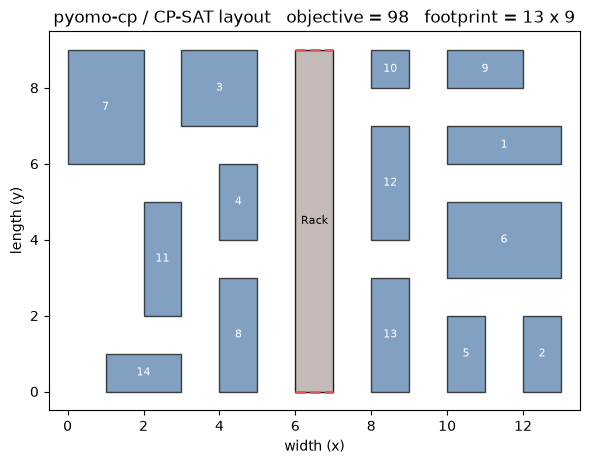

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6, 6))
for i in model.n:
    xi, yi = pyo.value(model.x[i]), pyo.value(model.y[i])
    wi, li = pyo.value(model.w[i]), pyo.value(model.l[i])
    is_rack = (i == 1)
    is_header = (l0[i] == 0)
    if is_header:
        ax.plot([xi, xi + max(wi, RACK_WID)], [yi, yi], color="#E45756",
                lw=2, ls="--", zorder=3)
        continue
    ax.add_patch(Rectangle((xi, yi), wi, li,
                           facecolor="#BAB0AC" if is_rack else "#4C78A8",
                           edgecolor="black", alpha=0.85 if is_rack else 0.7))
    ax.text(xi + wi / 2, yi + li / 2, "Rack" if is_rack else str(i - 1),
            ha="center", va="center", fontsize=8,
            color="white" if not is_rack else "black")

Lf, Wf = pyo.value(model.l_f), pyo.value(model.w_f)
ax.set_xlim(-0.5, Wf + 0.5)
ax.set_ylim(-0.5, Lf + 0.5)
ax.set_aspect("equal")
ax.set_title(f"pyomo-cp / CP-SAT layout   "
             f"objective = {round(pyo.value(model.obj))}   "
             f"footprint = {Wf:g} x {Lf:g}")
ax.set_xlabel("width (x)")
ax.set_ylabel("length (y)")
plt.tight_layout()
plt.show()

The same `pyomo.gdp` model the app reformulates to a MILP for Gurobi is solved
here, unchanged, by CP-SAT through `pyomo-cp` and returns the same optimum
(**98**). The only CP-specific step is the explicit `cp.discretize` call; the
model itself is identical.